# Import necessary libraries

In [19]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import ComplementNB, MultinomialNB, BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
import seaborn as sns

In [20]:
# Download required NLTK data
nltk.download('vader_lexicon')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\amirb\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amirb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Function to classify sentiment

In [21]:
def classify_sentiment(text):
    if not isinstance(text, str):  # Ensure text is a string
        text = ""

    score = sia.polarity_scores(text)['compound']

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Load training and testing datasets

In [22]:
train_df = pd.read_csv('train_dataset.csv')
test_df =  pd.read_csv('test_dataset.csv')

# Ensure all comments are strings before classification
train_df['Final_Comment'] = train_df['Final_Comment'].astype(str)
test_df['Final_Comment'] = test_df['Final_Comment'].astype(str)

# Apply sentiment classification to BOTH datasets
train_df['Sentiment'] = train_df['Final_Comment'].apply(classify_sentiment)
test_df['Sentiment'] = test_df['Final_Comment'].apply(classify_sentiment)

# Save updated datasets
train_df.to_csv('train_dataset_sentiment_VADER.csv', index=False)
test_df.to_csv('test_dataset_sentiment_VADER.csv', index=False)

print("✅ Sentiment classification completed for both datasets.")


✅ Sentiment classification completed for both datasets.


# Convert text labels into numeric labels

In [23]:
# (0=Negative, 1=Neutral, 2=Positive)
sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
train_df['Sentiment_Label'] = train_df['Sentiment'].map(sentiment_mapping)
test_df['Sentiment_Label'] = test_df['Sentiment'].map(sentiment_mapping)


# Feature Extraction using TF-IDF Vectorizer


In [24]:
# Verify if sentiment labels are successfully assigned
print("Train dataset sentiment distribution:\n", train_df['Sentiment'].value_counts())
print("Test dataset sentiment distribution:\n", test_df['Sentiment'].value_counts())

# Feature Extraction using TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_df['Final_Comment'])
X_test = vectorizer.transform(test_df['Final_Comment'])

y_train = train_df['Sentiment_Label']
y_test = test_df['Sentiment_Label']

Train dataset sentiment distribution:
 Sentiment
Neutral     3069
Positive    2836
Negative    1295
Name: count, dtype: int64
Test dataset sentiment distribution:
 Sentiment
Positive    735
Neutral     731
Negative    335
Name: count, dtype: int64


In [25]:
# Function to preprocess text (clean & tokenize)
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return words

In [26]:
# Get most common words in train dataset
train_words = train_df['Final_Comment'].apply(preprocess_text).sum()
train_common_words = Counter(train_words).most_common(10)
print("\n🔹 Most common words in training dataset:", train_common_words)

# Get most common words in test dataset
test_words = test_df['Final_Comment'].apply(preprocess_text).sum()
test_common_words = Counter(test_words).most_common(10)
print("\n🔹 Most common words in testing dataset:", test_common_words)


🔹 Most common words in training dataset: [('people', 787), ('bn', 643), ('umno', 571), ('win', 475), ('tun', 446), ('vote', 444), ('want', 420), ('party', 358), ('x', 349), ('best', 332)]

🔹 Most common words in testing dataset: [('bn', 169), ('people', 168), ('umno', 145), ('win', 122), ('vote', 118), ('party', 108), ('x', 106), ('want', 105), ('best', 102), ('change', 93)]


In [27]:
# Find most used word in positive sentiment
positive_words = train_df[train_df['Sentiment'] == 'Positive']['Final_Comment'].apply(preprocess_text).sum()
most_common_positive_word, _ = Counter(positive_words).most_common(1)[0]
print("\n✅ Most common word in Positive sentiment:", most_common_positive_word)

# Find most used word in negative sentiment
negative_words = train_df[train_df['Sentiment'] == 'Negative']['Final_Comment'].apply(preprocess_text).sum()
most_common_negative_word, _ = Counter(negative_words).most_common(1)[0]
print("\n✅ Most common word in Negative sentiment:", most_common_negative_word)


✅ Most common word in Positive sentiment: win

✅ Most common word in Negative sentiment: people


In [28]:
# Generate bag of words (BoW) related to most used words
vectorizer_bow = CountVectorizer(max_features=10, vocabulary=[most_common_positive_word, most_common_negative_word])
X_bow_train = vectorizer_bow.fit_transform(train_df['Final_Comment'])

# Convert BoW to DataFrame for visualization
bow_df = pd.DataFrame(X_bow_train.toarray(), columns=vectorizer_bow.get_feature_names_out())
print("\n📊 Bag of Words Representation (Top Words Related to Most Common Positive/Negative Word):\n", bow_df.head())


📊 Bag of Words Representation (Top Words Related to Most Common Positive/Negative Word):
    win  people
0    0       0
1    0       0
2    0       0
3    0       0
4    0       0


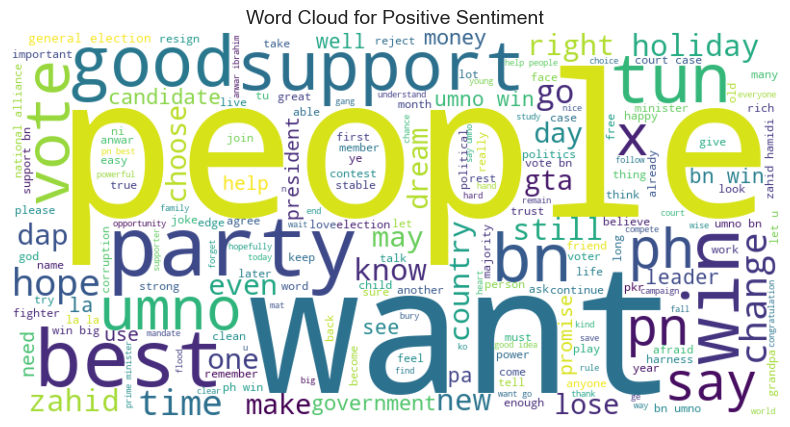

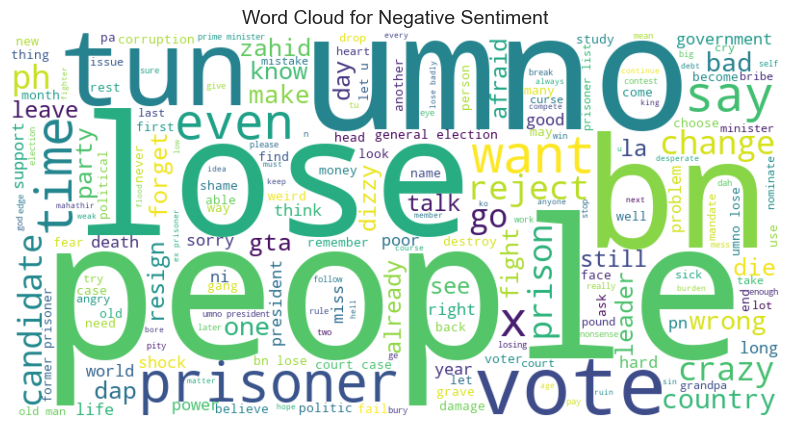

In [29]:
# Generate word clouds for most used words
def generate_wordcloud(words, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.show()

generate_wordcloud(positive_words, "Word Cloud for Positive Sentiment")
generate_wordcloud(negative_words, "Word Cloud for Negative Sentiment")

# Evaluation Of Naive Bayes Models

#  ComplementNB


In [30]:
CNB = ComplementNB()
CNB.fit(X_train, y_train)

predicted_cnb = CNB.predict(X_test)
accuracy_cnb = accuracy_score(y_test, predicted_cnb)

print('✅ ComplementNB model accuracy:', '{:04.2f}'.format(accuracy_cnb * 100), '%')
print('------------------------------------------------')
print('Confusion Matrix:\n', pd.DataFrame(confusion_matrix(y_test, predicted_cnb)))
print('------------------------------------------------')
print('Classification Report:\n', classification_report(y_test, predicted_cnb))

✅ ComplementNB model accuracy: 79.51 %
------------------------------------------------
Confusion Matrix:
      0    1    2
0  246   41   48
1   82  531  118
2   25   55  655
------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.73      0.72       335
           1       0.85      0.73      0.78       731
           2       0.80      0.89      0.84       735

    accuracy                           0.80      1801
   macro avg       0.78      0.78      0.78      1801
weighted avg       0.80      0.80      0.79      1801



# MultinomialNB

In [31]:
MNB = MultinomialNB()
MNB.fit(X_train, y_train)

predicted_mnb = MNB.predict(X_test)
accuracy_mnb = accuracy_score(y_test, predicted_mnb)

print('✅ MultinomialNB model accuracy:', '{:04.2f}'.format(accuracy_mnb * 100), '%')
print('------------------------------------------------')
print('Confusion Matrix:\n', pd.DataFrame(confusion_matrix(y_test, predicted_mnb)))
print('------------------------------------------------')
print('Classification Report:\n', classification_report(y_test, predicted_mnb))

✅ MultinomialNB model accuracy: 77.40 %
------------------------------------------------
Confusion Matrix:
      0    1    2
0  119   95  121
1    3  605  123
2    4   61  670
------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.36      0.52       335
           1       0.80      0.83      0.81       731
           2       0.73      0.91      0.81       735

    accuracy                           0.77      1801
   macro avg       0.82      0.70      0.71      1801
weighted avg       0.80      0.77      0.76      1801



# BernoulliNB

In [32]:
BNB = BernoulliNB()
BNB.fit(X_train, y_train)

predicted_bnb = BNB.predict(X_test)
accuracy_bnb = accuracy_score(y_test, predicted_bnb)

print('✅ BernoulliNB model accuracy:', '{:04.2f}'.format(accuracy_bnb * 100), '%')
print('------------------------------------------------')
print('Confusion Matrix:\n', pd.DataFrame(confusion_matrix(y_test, predicted_bnb)))
print('------------------------------------------------')
print('Classification Report:\n', classification_report(y_test, predicted_bnb))


✅ BernoulliNB model accuracy: 80.29 %
------------------------------------------------
Confusion Matrix:
      0    1    2
0  124  126   85
1    5  687   39
2   14   86  635
------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.37      0.52       335
           1       0.76      0.94      0.84       731
           2       0.84      0.86      0.85       735

    accuracy                           0.80      1801
   macro avg       0.82      0.72      0.74      1801
weighted avg       0.81      0.80      0.79      1801



C:\Users\amirb\AppData\Local\Temp\ipykernel_8356\2939480805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


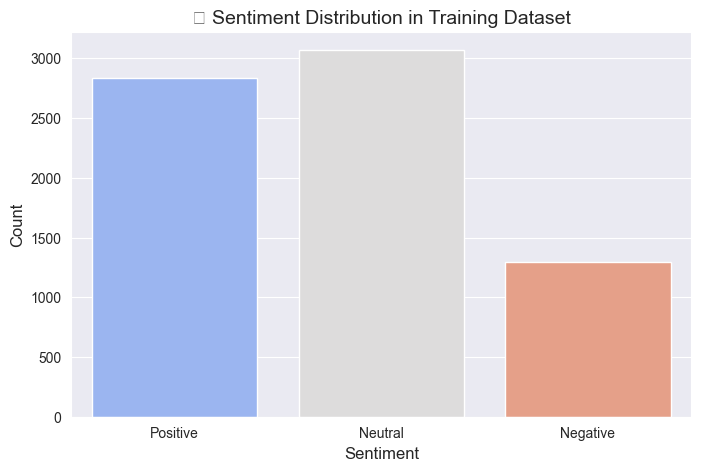

C:\Users\amirb\AppData\Local\Temp\ipykernel_8356\2939480805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


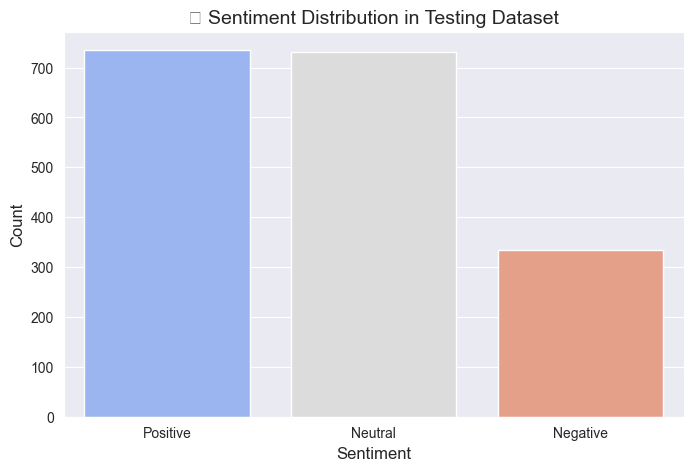

In [33]:
def plot_sentiment_distribution(df, title):
    plt.figure(figsize=(8,5))
    sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
    plt.title(title, fontsize=14)
    plt.xlabel("Sentiment", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.show()

plot_sentiment_distribution(train_df, "🔹 Sentiment Distribution in Training Dataset")
plot_sentiment_distribution(test_df, "🔹 Sentiment Distribution in Testing Dataset")

C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


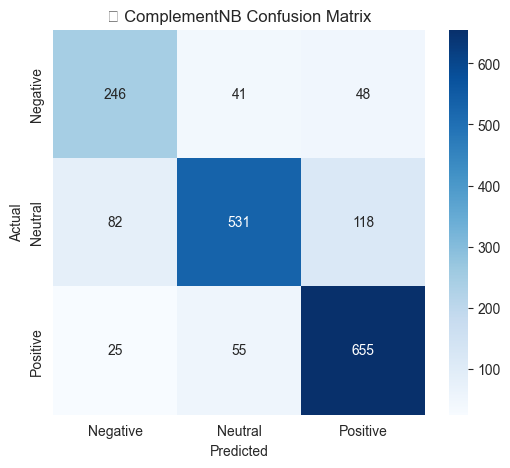

C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


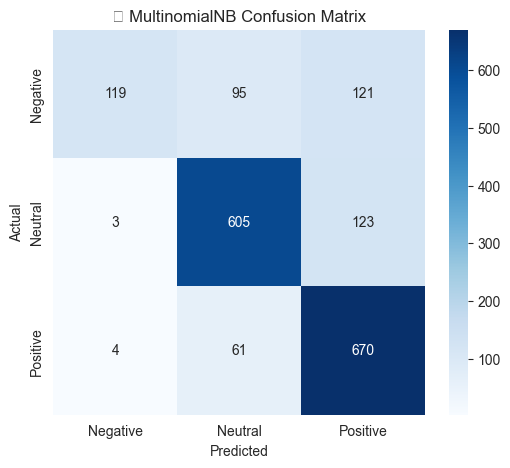

C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


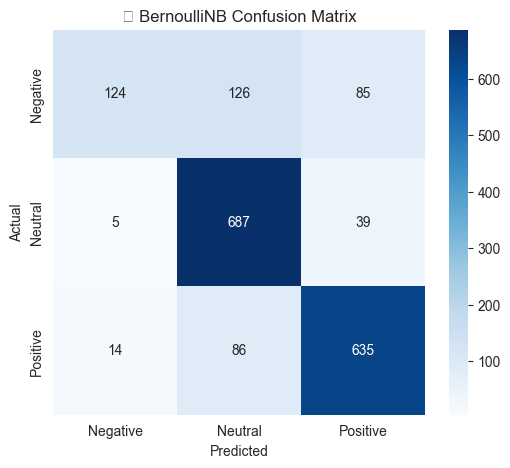

In [34]:
def plot_confusion_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

# Generate Confusion Matrices for each model
plot_confusion_matrix(y_test, predicted_cnb, "🔹 ComplementNB Confusion Matrix")
plot_confusion_matrix(y_test, predicted_mnb, "🔹 MultinomialNB Confusion Matrix")
plot_confusion_matrix(y_test, predicted_bnb, "🔹 BernoulliNB Confusion Matrix")

C:\Users\amirb\AppData\Local\Temp\ipykernel_8356\3712796183.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette='coolwarm')
C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


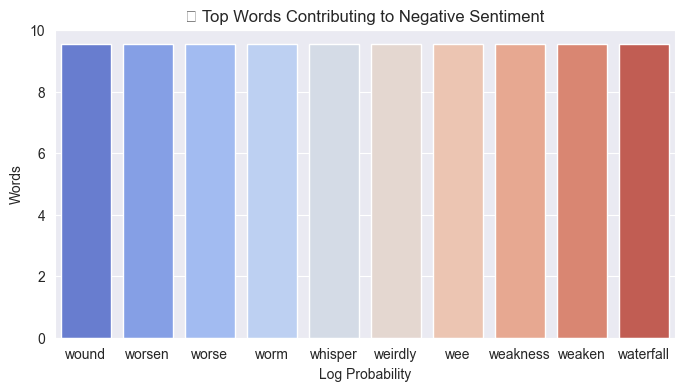

C:\Users\amirb\AppData\Local\Temp\ipykernel_8356\3712796183.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette='coolwarm')
C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


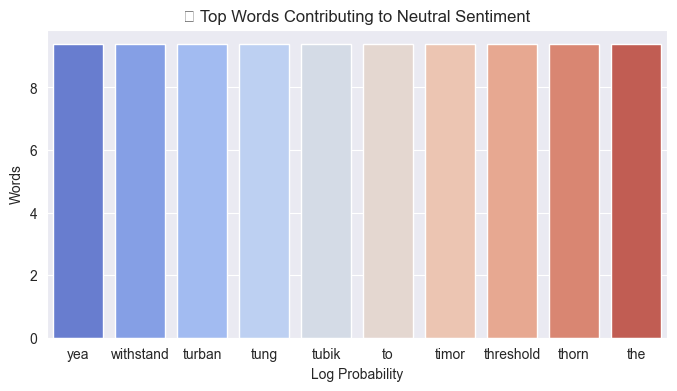

C:\Users\amirb\AppData\Local\Temp\ipykernel_8356\3712796183.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette='coolwarm')
C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


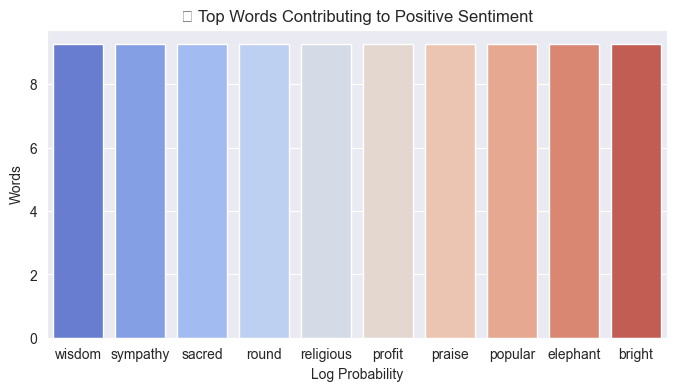

In [35]:
# Extract feature importance for ComplementNB
feature_names = vectorizer.get_feature_names_out()
feature_importance = CNB.feature_log_prob_  # Use log probabilities instead of coefficients

# Get top 10 most important words for each sentiment
for i, label in enumerate(["Negative", "Neutral", "Positive"]):
    top_features = sorted(zip(feature_importance[i], feature_names), reverse=True)[:10]
    words, scores = zip(*top_features)

    plt.figure(figsize=(8,4))
    sns.barplot(x=list(scores), y=list(words), palette='coolwarm')
    plt.title(f"🔹 Top Words Contributing to {label} Sentiment")
    plt.xlabel("Log Probability")
    plt.ylabel("Words")
    plt.show()


C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


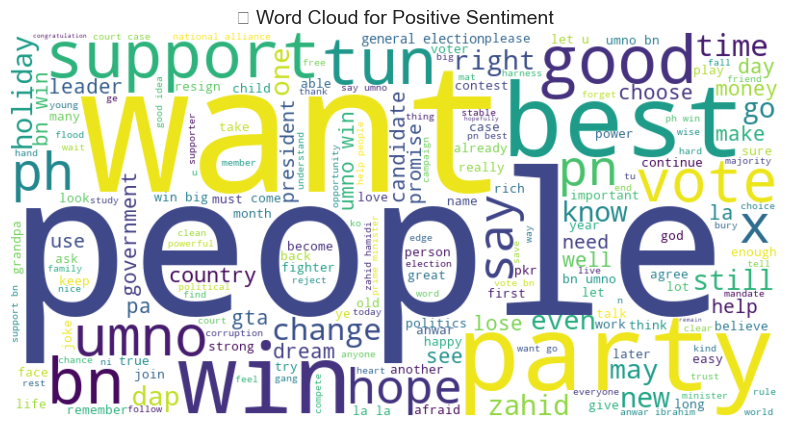

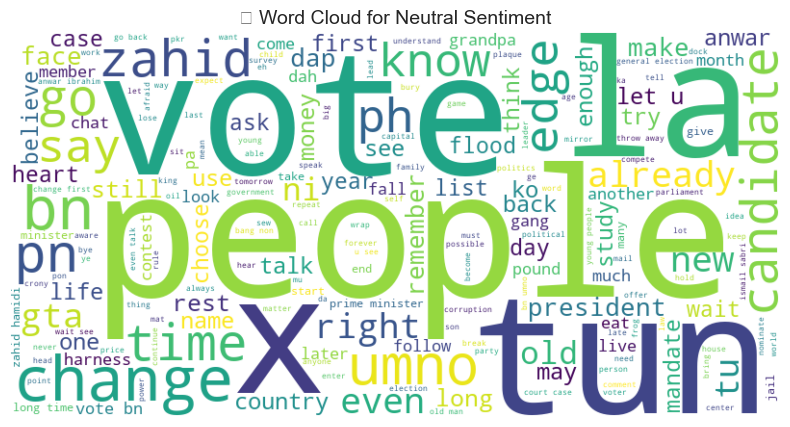

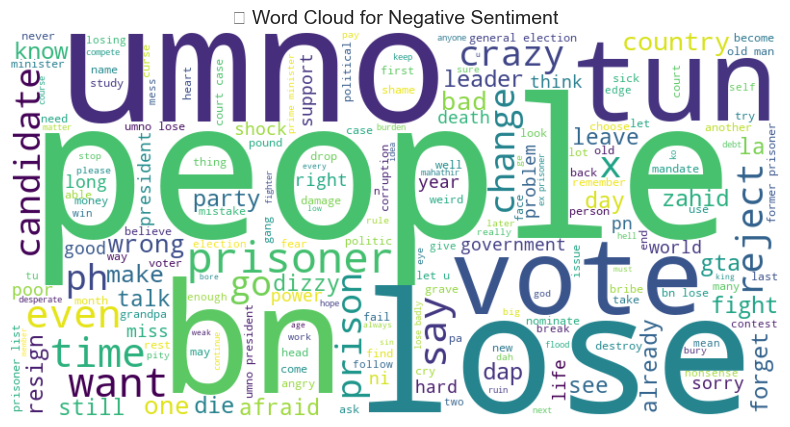

In [36]:
# Generate word clouds for each sentiment category
for sentiment in ["Positive", "Neutral", "Negative"]:
    words = train_df[train_df['Sentiment'] == sentiment]['Final_Comment'].apply(preprocess_text).sum()
    generate_wordcloud(words, f"🔹 Word Cloud for {sentiment} Sentiment")